# 03 — Análisis Exploratorio de Datos (EDA)

**Pipeline**: analiza `dataset_final.csv` (salida de 02). No genera archivos de datos.
**Anterior**: `02_features_competencias.ipynb`  |  **Siguiente**: `04_preprocessing.ipynb`

> **Nota v6**: el dataset incluye `edad_relativa`, `mes_nacimiento`, `trimestre_nacimiento`
> y `pct_asignaturas__X` en lugar de conteos absolutos por competencia.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Detectar raiz TFM desde cualquier subcarpeta
_cwd = Path('.').resolve()
BASE_DIR = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'data').exists()),
    _cwd.parent
)
P_DATA    = BASE_DIR / 'data' / 'dataset_v11.csv'

CAT_ORDER  = ['buen_alumno', 'en_riesgo', 'con_dificultades']
CAT_COLORS = {'buen_alumno': '#2ecc71', 'en_riesgo': '#f39c12', 'con_dificultades': '#e74c3c'}
PALETTE    = [CAT_COLORS[c] for c in CAT_ORDER]
COMPS      = ['LING', 'STEM', 'SOC', 'PERS']  # 4 bloques (V7: CCL+CP->LING, CC+CCEC->SOC, CPSAA+CE+OTROS->PERS)

In [2]:
df = pd.read_csv(P_DATA)
df['categoria_target'] = pd.Categorical(df['categoria_target'], categories=CAT_ORDER, ordered=True)

print(f'Shape: {df.shape}')
print(f'Alumnos únicos: {df["GuidAlumno"].nunique()}')
print(f'Ejercicios: {sorted(df["Ejercicio"].unique())}')
print(f'\nTarget:\n{df["categoria_target"].value_counts()}')
# edad_relativa SOLO para EDA descriptiva (en el modelo se centra dentro del pipeline,
# por fold, sin leakage). Aqui es exploracion, asi que se recompone globalmente.
if 'edad_inicio' in df.columns and 'edad_relativa' not in df.columns:
    df['edad_relativa'] = df['edad_inicio'] - df.groupby(['NivCurso','Ejercicio'])['edad_inicio'].transform('mean')


Shape: (1205, 59)
Alumnos únicos: 836
Ejercicios: [2010, 2011, 2018, 2019, 2020]

Target:
categoria_target
buen_alumno         867
en_riesgo           213
con_dificultades    125
Name: count, dtype: int64


## 1. Vista general y datos faltantes

In [3]:
# Resumen de missings por bloque de columnas
def missing_summary(df):
    s = pd.DataFrame({
        'tipo': df.dtypes,
        'n_nulos': df.isna().sum(),
        'pct_nulos': df.isna().mean() * 100,
        'n_validos': df.notna().sum(),
    })
    return s[s['n_nulos'] > 0].sort_values('pct_nulos', ascending=False)

miss = missing_summary(df)
print(f'Columnas con valores faltantes: {len(miss)} de {len(df.columns)}')
miss

Columnas con valores faltantes: 31 de 60


,tipo,n_nulos,pct_nulos,n_validos
mat__Religion_Valores,float64,1106,91.784,99
mat__Tecnologia,float64,931,77.261,274
pct_asignaturas__PERS,float64,898,74.523,307
nota_max__PERS,float64,898,74.523,307
nota_media__PERS,float64,898,74.523,307
nota_min__PERS,float64,898,74.523,307
pct_aprobado__PERS,float64,898,74.523,307
mat__Sociales,float64,759,62.988,446
mat__Lengua_Extranjera,float64,317,26.307,888
mat__Educacion_Artistica,float64,305,25.311,900


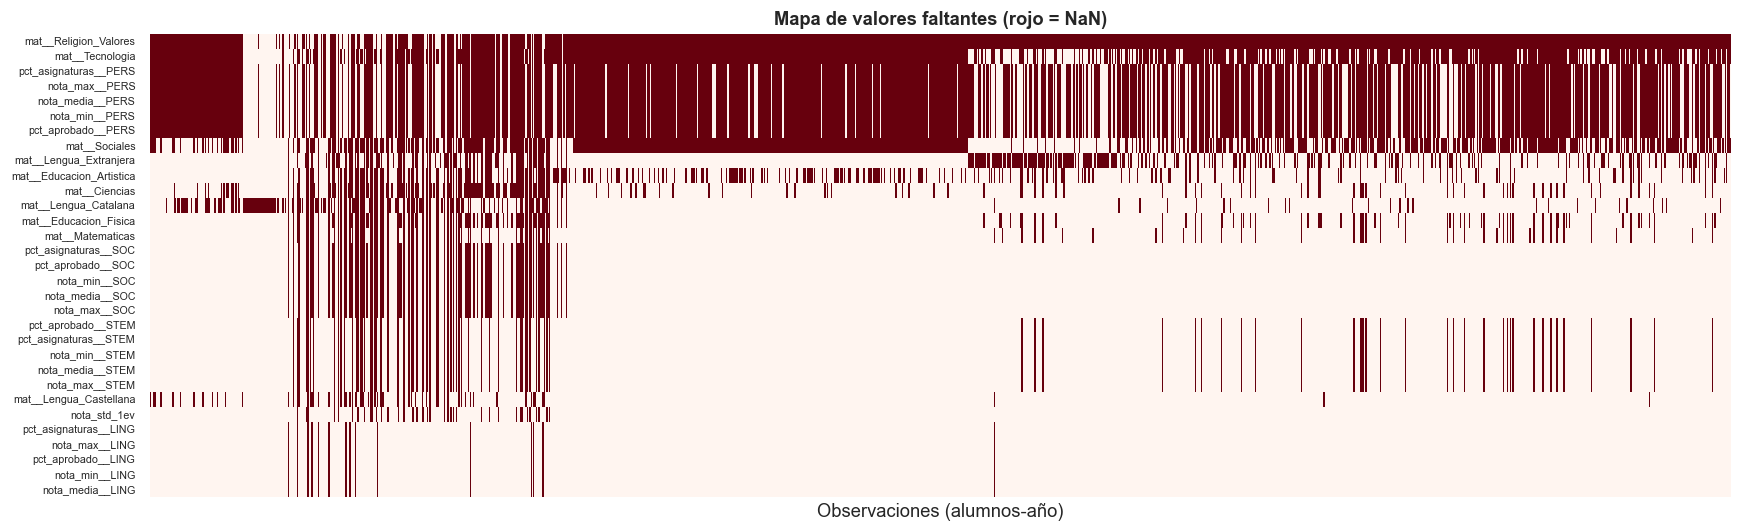


Alumnos sin features CCL: 15 (1.2%)
→ Son alumnos sin notas en 1EV (solo_2EV o notas puramente cualitativas)


In [4]:
# Heatmap de missings — columnas ordenadas por % nulo
miss_cols = miss.index.tolist()
miss_matrix = df[miss_cols].isna().astype(int)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(miss_matrix.T, cmap='Reds', cbar=False, ax=ax,
            yticklabels=miss_cols, xticklabels=False)
ax.set_title('Mapa de valores faltantes (rojo = NaN)', fontweight='bold')
ax.set_xlabel('Observaciones (alumnos-año)')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

# Patrón: alumnos sin features de competencias
sin_comp = df['nota_media__LING'].isna().sum()
print(f'\nAlumnos sin features CCL: {sin_comp} ({sin_comp/len(df)*100:.1f}%)')
print('→ Son alumnos sin notas en 1EV (solo_2EV o notas puramente cualitativas)')

## 2. Target: balance y distribución

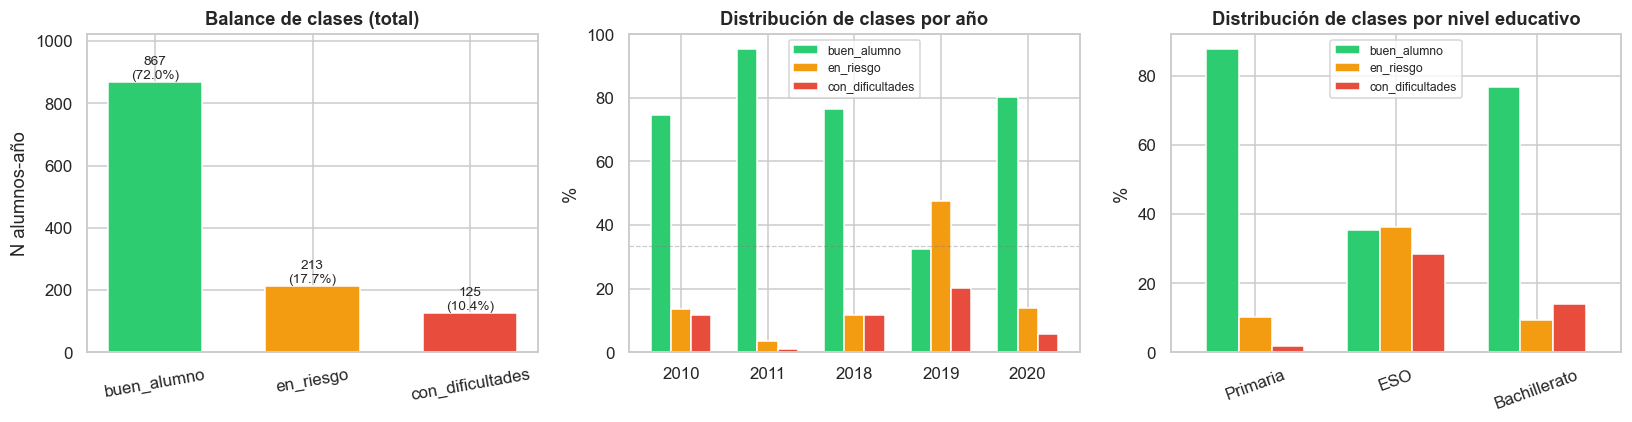

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Balance general ---
counts = df['categoria_target'].value_counts()[CAT_ORDER]
bars = axes[0].bar(CAT_ORDER, counts.values, color=PALETTE, edgecolor='white', width=0.6)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Balance de clases (total)', fontweight='bold')
axes[0].set_ylabel('N alumnos-año')
axes[0].set_ylim(0, counts.max()*1.18)
axes[0].tick_params(axis='x', rotation=10)

# --- Por ejercicio ---
ct_anio = df.groupby('Ejercicio')['categoria_target'].value_counts(normalize=True).unstack()[CAT_ORDER] * 100
ct_anio.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white', width=0.7)
axes[1].set_title('Distribución de clases por año', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)
axes[1].axhline(33.3, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# --- Por nivel ---
niv_order = (df.groupby('NivEstudio')['GuidAlumno']
               .count().sort_values(ascending=False).index.tolist())
ct_niv = (df.dropna(subset=['NivEstudio'])
            .groupby('NivEstudio')['categoria_target']
            .value_counts(normalize=True).unstack()[CAT_ORDER] * 100)
ct_niv = ct_niv.reindex(niv_order)
ct_niv.plot(kind='bar', ax=axes[2], color=PALETTE, edgecolor='white', width=0.7)
axes[2].set_title('Distribución de clases por nivel educativo', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Cobertura temporal y por nivel educativo

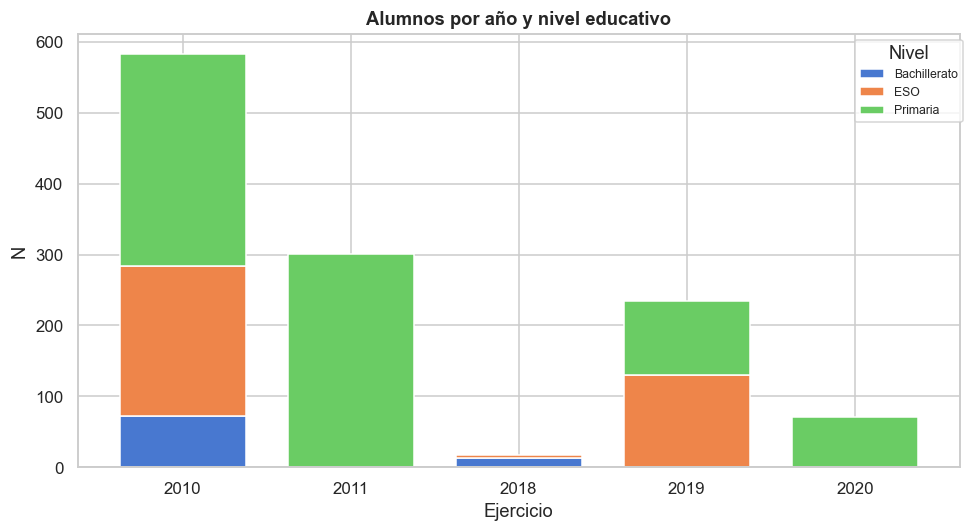

Alumnos por ejercicio:
Ejercicio
2010    582
2011    301
2018     17
2019    234
2020     71


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ct = (df.dropna(subset=['NivEstudio'])
        .groupby(['Ejercicio', 'NivEstudio'])['GuidAlumno'].count().unstack(fill_value=0))
ct.plot(kind='bar', ax=ax, edgecolor='white', width=0.75, stacked=True)
ax.set_title('Alumnos por año y nivel educativo', fontweight='bold')
ax.set_xlabel('Ejercicio'); ax.set_ylabel('N'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Nivel', fontsize=8, bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()
print('Alumnos por ejercicio:'); print(df['Ejercicio'].value_counts().sort_index().to_string())

## 4. Features base de 1EV (notas globales)

Estas son las variables más directas: notas agregadas de todas las asignaturas en el primer trimestre.

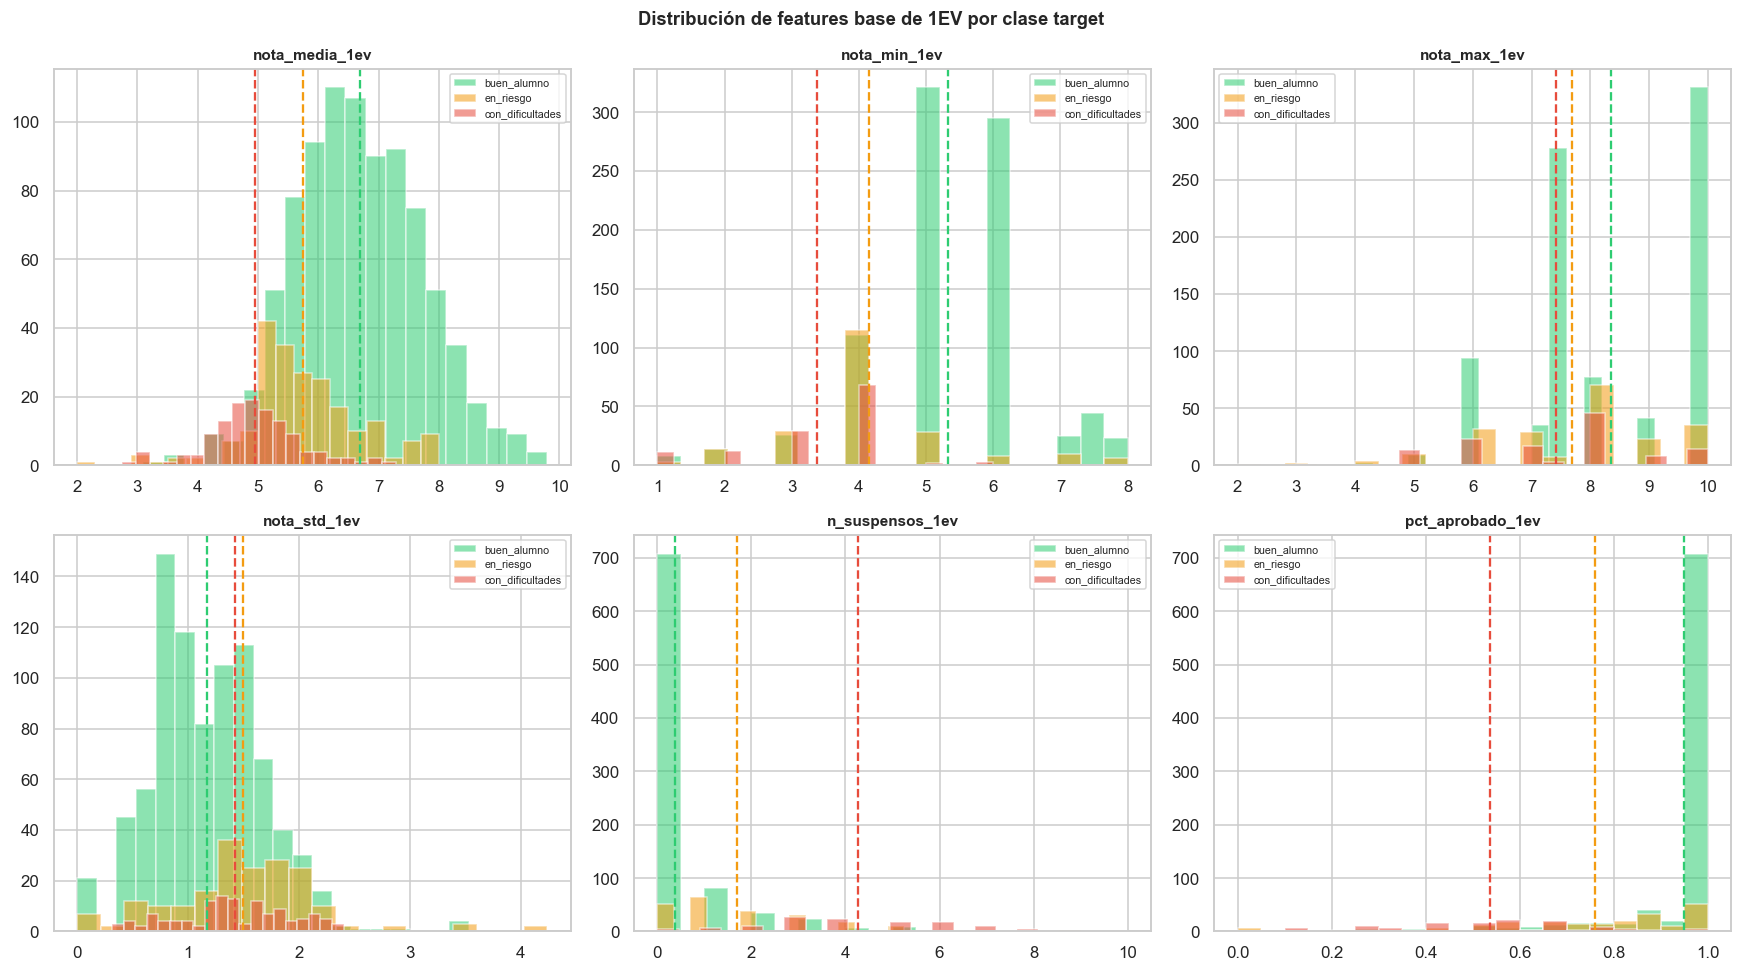

In [7]:
BASE_FEATS = ['nota_media_1ev', 'nota_min_1ev', 'nota_max_1ev',
              'nota_std_1ev', 'n_suspensos_1ev', 'pct_aprobado_1ev']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(BASE_FEATS):
    for cat, color in CAT_COLORS.items():
        data = df.loc[df['categoria_target'] == cat, col].dropna()
        axes[i].hist(data, bins=20, alpha=0.55, color=color, label=cat, edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)
    # Medias verticales
    for cat, color in CAT_COLORS.items():
        m = df.loc[df['categoria_target'] == cat, col].mean()
        if not np.isnan(m):
            axes[i].axvline(m, color=color, linestyle='--', linewidth=1.5)

fig.suptitle('Distribución de features base de 1EV por clase target',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:7: F

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,


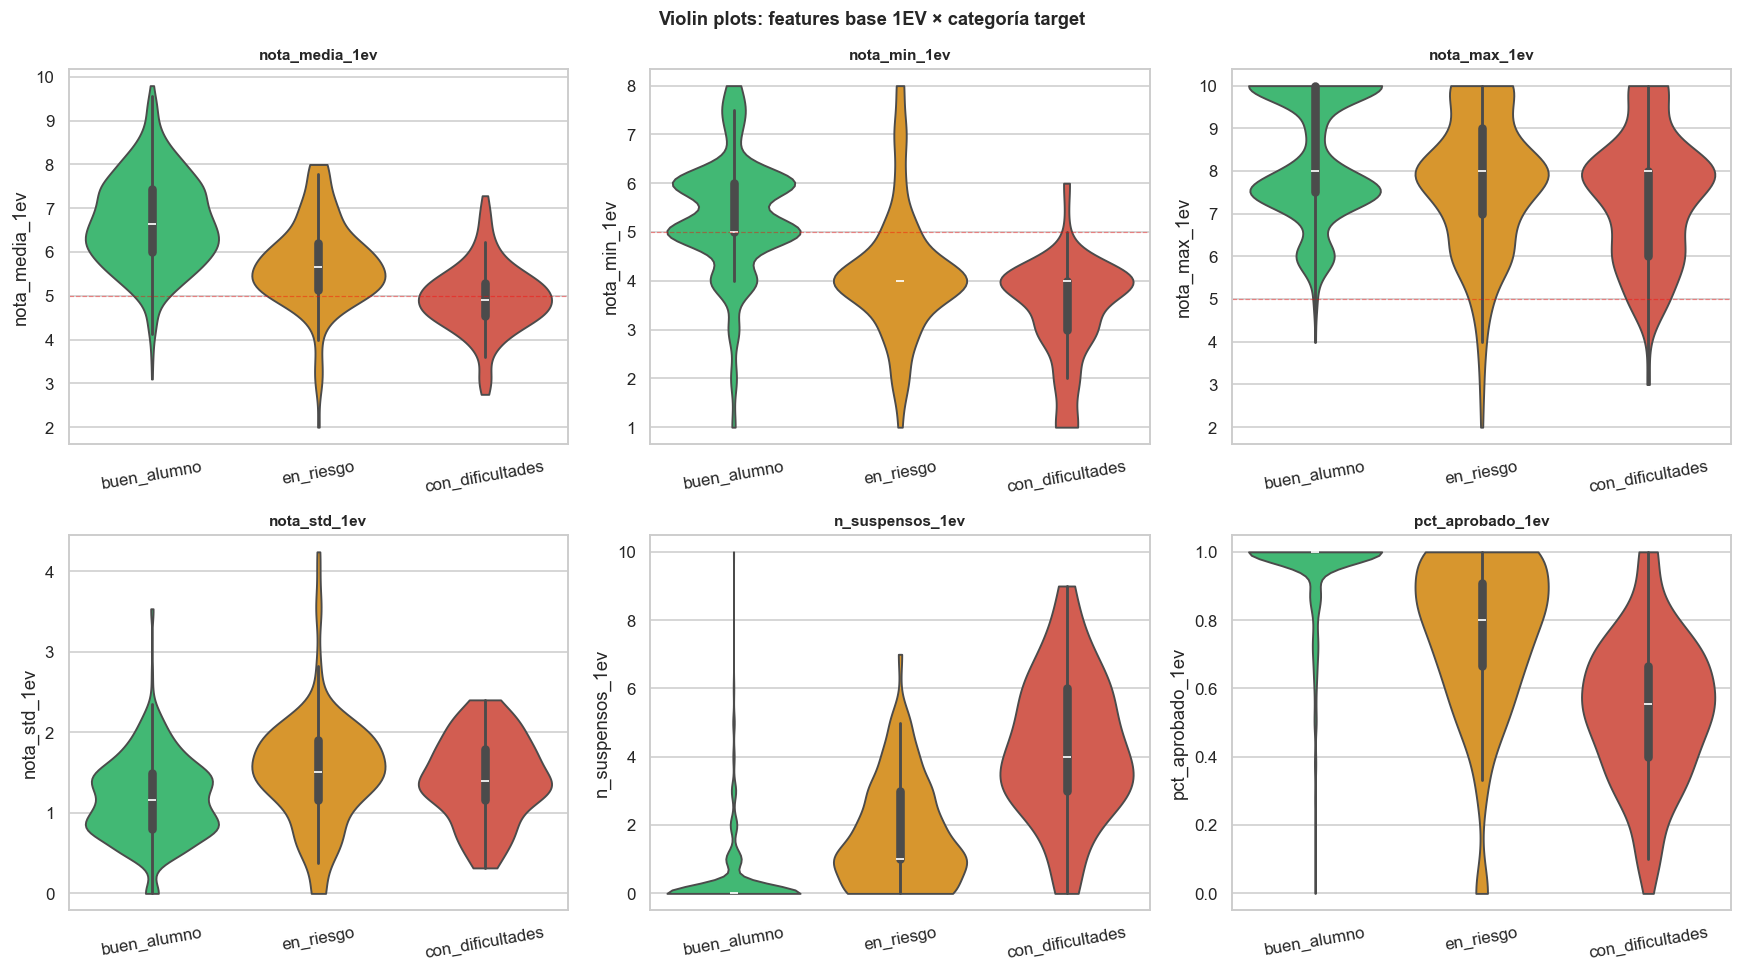

Media por clase target:
                  nota_media_1ev  nota_min_1ev  nota_max_1ev  nota_std_1ev  n_suspensos_1ev  pct_aprobado_1ev
categoria_target                                                                                             
buen_alumno                6.700         5.330         8.350         1.180            0.370             0.950
en_riesgo                  5.740         4.150         7.690         1.500            1.700             0.760
con_dificultades           4.950         3.380         7.420         1.420            4.260             0.540


C:\Users\emili\AppData\Local\Temp\ipykernel_25564\131708384.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('categoria_target')[BASE_FEATS].mean().round(2).to_string())


In [8]:
# Violin plots — más informativos que boxplots para ver bimodalidad
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(BASE_FEATS):
    data_plot = df[['categoria_target', col]].dropna()
    sns.violinplot(data=data_plot, x='categoria_target', y=col,
                   order=CAT_ORDER, palette=PALETTE,
                   inner='box', ax=axes[i], cut=0)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    if col in ('nota_media_1ev', 'nota_min_1ev', 'nota_max_1ev'):
        axes[i].axhline(5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
    axes[i].tick_params(axis='x', rotation=10)

fig.suptitle('Violin plots: features base 1EV × categoría target',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Estadísticos por clase
print('Media por clase target:')
print(df.groupby('categoria_target')[BASE_FEATS].mean().round(2).to_string())

In [9]:
# Test Kruskal-Wallis: ¿hay diferencia significativa entre clases?
print('Kruskal-Wallis H-test (H0: las 3 clases tienen la misma distribución):')
print(f'{"Feature":<25}  {"H-stat":>8}  {"p-value":>10}  {"Significativo":>13}')
print('-' * 65)
for col in BASE_FEATS:
    groups = [df.loc[df['categoria_target'] == c, col].dropna().values for c in CAT_ORDER]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2: continue
    h, p = stats.kruskal(*groups)
    sig = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else ('* p<0.05' if p < 0.05 else 'ns'))
    print(f'{col:<25}  {h:>8.2f}  {p:>10.4f}  {sig:>13}')

Kruskal-Wallis H-test (H0: las 3 clases tienen la misma distribución):
Feature                      H-stat     p-value  Significativo
-----------------------------------------------------------------
nota_media_1ev               324.54      0.0000    *** p<0.001
nota_min_1ev                 345.71      0.0000    *** p<0.001
nota_max_1ev                  37.90      0.0000    *** p<0.001
nota_std_1ev                  66.91      0.0000    *** p<0.001
n_suspensos_1ev              544.82      0.0000    *** p<0.001
pct_aprobado_1ev             522.17      0.0000    *** p<0.001


## 5. Variables demográficas

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['IsRepetidor', 'categoria_target'])
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Sexo_label', 'categoria_target'])
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warnin

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['edad_relativa']),
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.dropna(subset=['HermanosPosicion']),
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\982705008.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['trimestre_label', 'categoria_target'])


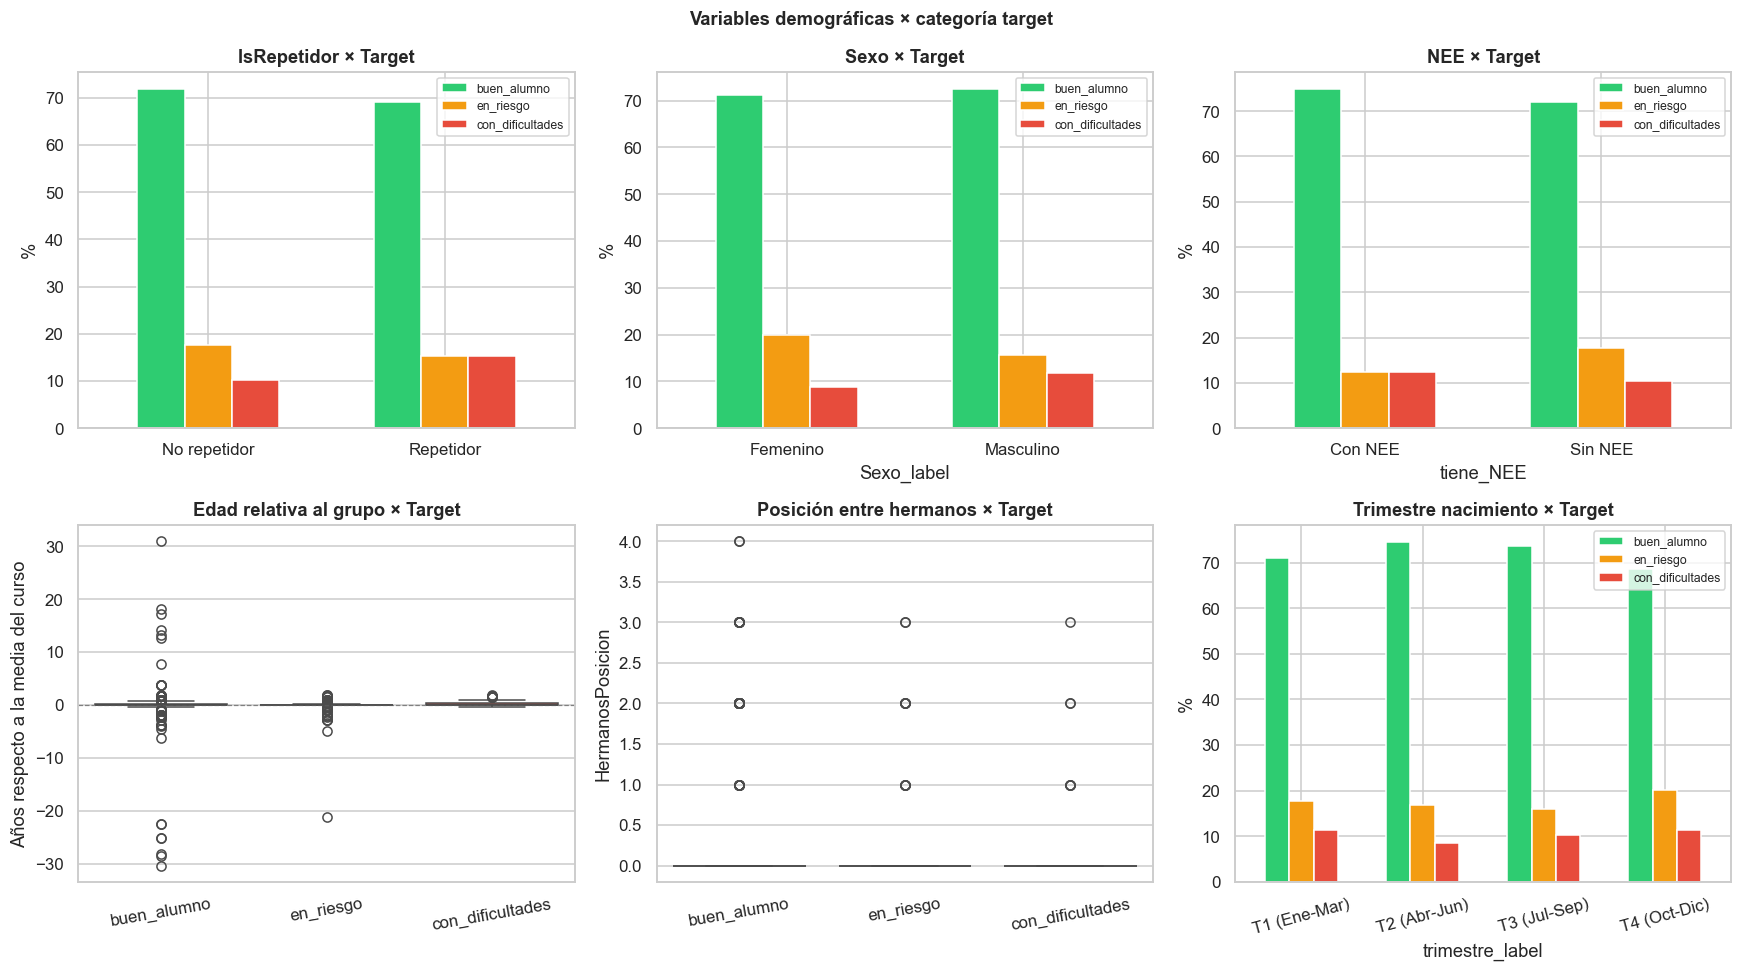

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- IsRepetidor ---
rep = (df.dropna(subset=['IsRepetidor'])
         .groupby(['IsRepetidor', 'categoria_target'])
         .size().unstack(fill_value=0)[CAT_ORDER])
rep_pct = rep.div(rep.sum(axis=1), axis=0) * 100
rep_pct.index = ['No repetidor', 'Repetidor']
rep_pct.plot(kind='bar', ax=axes[0, 0], color=PALETTE, edgecolor='white', width=0.6)
axes[0, 0].set_title('IsRepetidor × Target', fontweight='bold')
axes[0, 0].set_ylabel('%'); axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(fontsize=8)

# --- Sexo ---
sexo_map = {0: 'Masculino', 1: 'Femenino'}
df['Sexo_label'] = df['Sexo'].map(sexo_map)
sexo = (df.dropna(subset=['Sexo_label'])
          .groupby(['Sexo_label', 'categoria_target'])
          .size().unstack(fill_value=0)[CAT_ORDER])
sexo_pct = sexo.div(sexo.sum(axis=1), axis=0) * 100
sexo_pct.plot(kind='bar', ax=axes[0, 1], color=PALETTE, edgecolor='white', width=0.6)
axes[0, 1].set_title('Sexo × Target', fontweight='bold')
axes[0, 1].set_ylabel('%'); axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(fontsize=8)

# --- IdNEE ---
df['tiene_NEE'] = (df['IdNEE'].notna() & (df['IdNEE'] > 0)).map({True: 'Con NEE', False: 'Sin NEE'})
nee = (df.groupby(['tiene_NEE', 'categoria_target'])
         .size().unstack(fill_value=0)[CAT_ORDER])
nee_pct = nee.div(nee.sum(axis=1), axis=0) * 100
nee_pct.plot(kind='bar', ax=axes[0, 2], color=PALETTE, edgecolor='white', width=0.6)
axes[0, 2].set_title('NEE × Target', fontweight='bold')
axes[0, 2].set_ylabel('%'); axes[0, 2].tick_params(axis='x', rotation=0)
axes[0, 2].legend(fontsize=8)

# --- Edad relativa (diferencia respecto a media del grupo NivCurso x Ejercicio) ---
sns.boxplot(data=df.dropna(subset=['edad_relativa']),
            x='categoria_target', y='edad_relativa',
            order=CAT_ORDER, palette=PALETTE, ax=axes[1, 0])
axes[1, 0].set_title('Edad relativa al grupo × Target', fontweight='bold')
axes[1, 0].set_xlabel(''); axes[1, 0].tick_params(axis='x', rotation=10)
axes[1, 0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1, 0].set_ylabel('Años respecto a la media del curso')

# --- Posicion hermanos ---
sns.boxplot(data=df.dropna(subset=['HermanosPosicion']),
            x='categoria_target', y='HermanosPosicion',
            order=CAT_ORDER, palette=PALETTE, ax=axes[1, 1])
axes[1, 1].set_title('Posición entre hermanos × Target', fontweight='bold')
axes[1, 1].set_xlabel(''); axes[1, 1].tick_params(axis='x', rotation=10)

# --- Trimestre de nacimiento (efecto edad relativa) ---
trim_map = {1: 'T1 (Ene-Mar)', 2: 'T2 (Abr-Jun)', 3: 'T3 (Jul-Sep)', 4: 'T4 (Oct-Dic)'}
df['trimestre_label'] = df['trimestre_nacimiento'].map(trim_map)
trim = (df.dropna(subset=['trimestre_label'])
          .groupby(['trimestre_label', 'categoria_target'])
          .size().unstack(fill_value=0)[CAT_ORDER])
trim_pct = trim.div(trim.sum(axis=1), axis=0) * 100
trim_pct.plot(kind='bar', ax=axes[1, 2], color=PALETTE, edgecolor='white', width=0.6)
axes[1, 2].set_title('Trimestre nacimiento × Target', fontweight='bold')
axes[1, 2].set_ylabel('%'); axes[1, 2].tick_params(axis='x', rotation=15)
axes[1, 2].legend(fontsize=8)

fig.suptitle('Variables demográficas × categoría target', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Asistencia en 1EV

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\1157168949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\1157168949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\1157168949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_target', y=col,


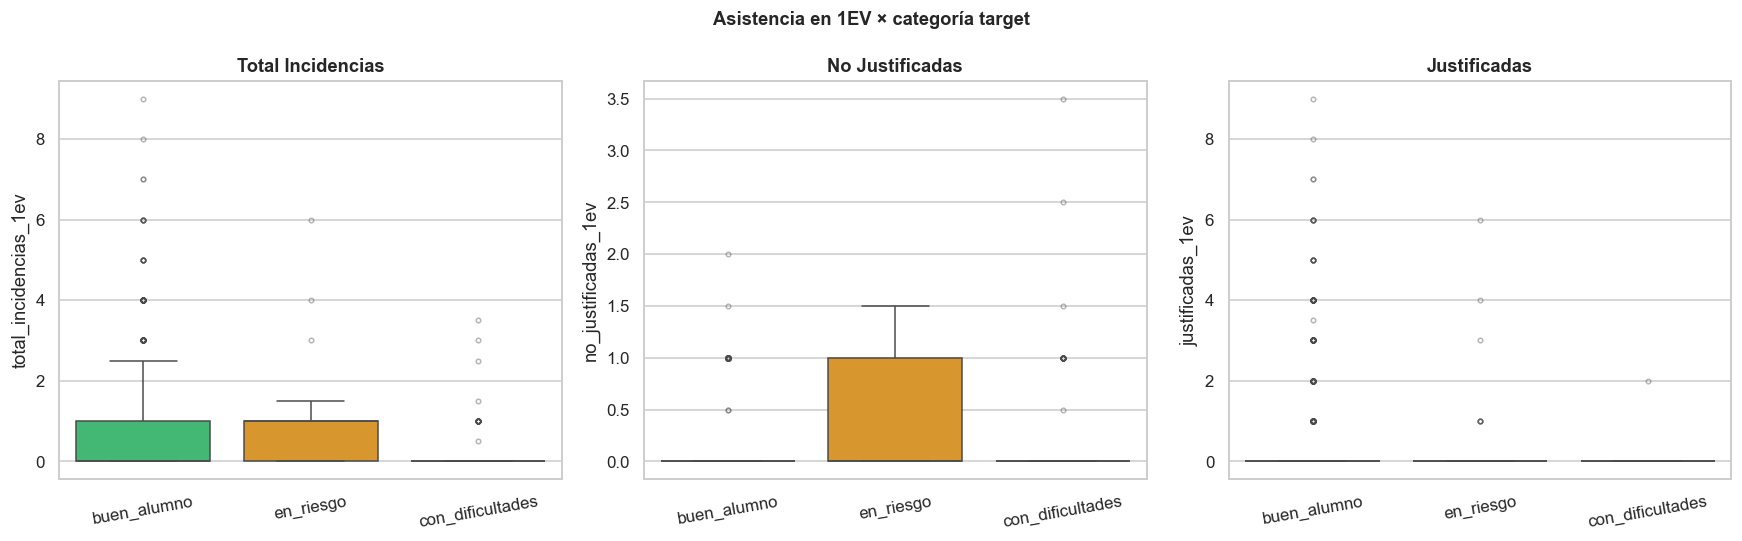

% alumnos con 0 faltas totales en 1EV por clase:
  buen_alumno         : 73.7%  (media faltas: 0.53)
  en_riesgo           : 47.9%  (media faltas: 0.57)
  con_dificultades    : 84.0%  (media faltas: 0.21)

Kruskal-Wallis asistencia:
  total_incidencias_1ev           H=48.38  p=0.0000  ***
  no_justificadas_1ev             H=186.44  p=0.0000  ***
  justificadas_1ev                H=46.98  p=0.0000  ***


In [11]:
ASIST_COLS = ['total_incidencias_1ev', 'no_justificadas_1ev', 'justificadas_1ev']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(ASIST_COLS):
    sns.boxplot(data=df, x='categoria_target', y=col,
                order=CAT_ORDER, palette=PALETTE,
                ax=axes[i], showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col.replace('_1ev', '').replace('_', ' ').title(),
                       fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=10)

fig.suptitle('Asistencia en 1EV × categoría target', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Porcentaje con 0 faltas por clase
print('% alumnos con 0 faltas totales en 1EV por clase:')
for cat in CAT_ORDER:
    sub = df[df['categoria_target'] == cat]
    pct = (sub['total_incidencias_1ev'] == 0).mean() * 100
    print(f'  {cat:<20}: {pct:.1f}%  (media faltas: {sub["total_incidencias_1ev"].mean():.2f})')

print('\nKruskal-Wallis asistencia:')
for col in ASIST_COLS:
    groups = [df.loc[df['categoria_target'] == c, col].dropna().values for c in CAT_ORDER]
    h, p = stats.kruskal(*groups)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {col:<30}  H={h:.2f}  p={p:.4f}  {sig}')

## 7. Features competenciales (CCL, STEM, CP, CCEC, CC, CPSAA, CE, OTROS)

Para cada competencia se tienen 6 métricas de 1EV: `nota_media`, `nota_min`, `nota_max`, `n_asignaturas`, `pct_aprobado`, `n_suspensos`.

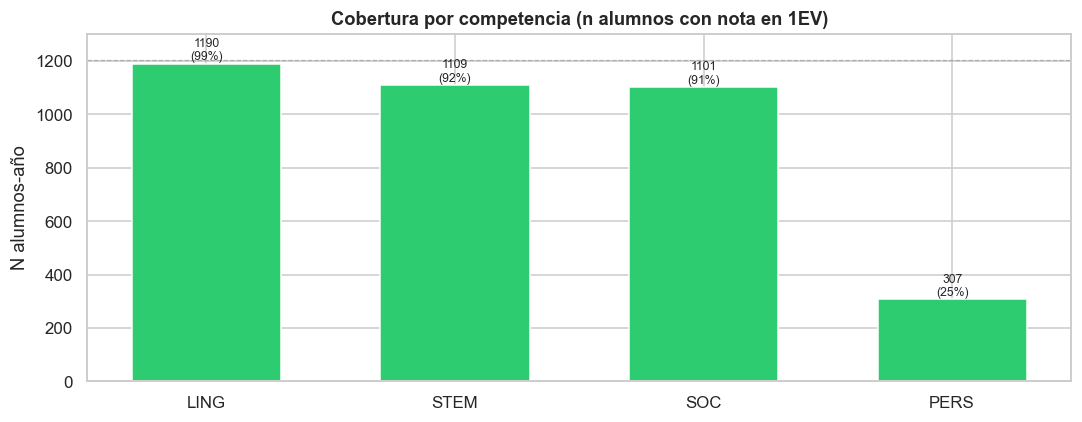

NOTA: CE tiene solo ~8 observaciones — no usable como feature en modelado general.


In [12]:
# Cobertura por competencia (% alumnos con dato)
comp_coverage = {}
for comp in COMPS:
    col = f'nota_media__{comp}'
    if col in df.columns:
        comp_coverage[comp] = df[col].notna().sum()

fig, ax = plt.subplots(figsize=(10, 4))
comps_ord = sorted(comp_coverage, key=comp_coverage.get, reverse=True)
vals = [comp_coverage[c] for c in comps_ord]
colors_cov = ['#e74c3c' if v < 100 else '#f39c12' if v < 300 else '#2ecc71' for v in vals]
bars = ax.bar(comps_ord, vals, color=colors_cov, edgecolor='white', width=0.6)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{v}\n({v/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=8)
ax.axhline(len(df), color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_title('Cobertura por competencia (n alumnos con nota en 1EV)',
              fontweight='bold')
ax.set_ylabel('N alumnos-año')
ax.set_ylim(0, len(df)*1.08)
plt.tight_layout()
plt.show()

print('NOTA: CE tiene solo ~8 observaciones — no usable como feature en modelado general.')

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\2076462730.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_data[comp] = df.groupby('categoria_target')[col].mean()
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\2076462730.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_data[comp] = df.groupby('categoria_target')[col].mean()
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\2076462730.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future

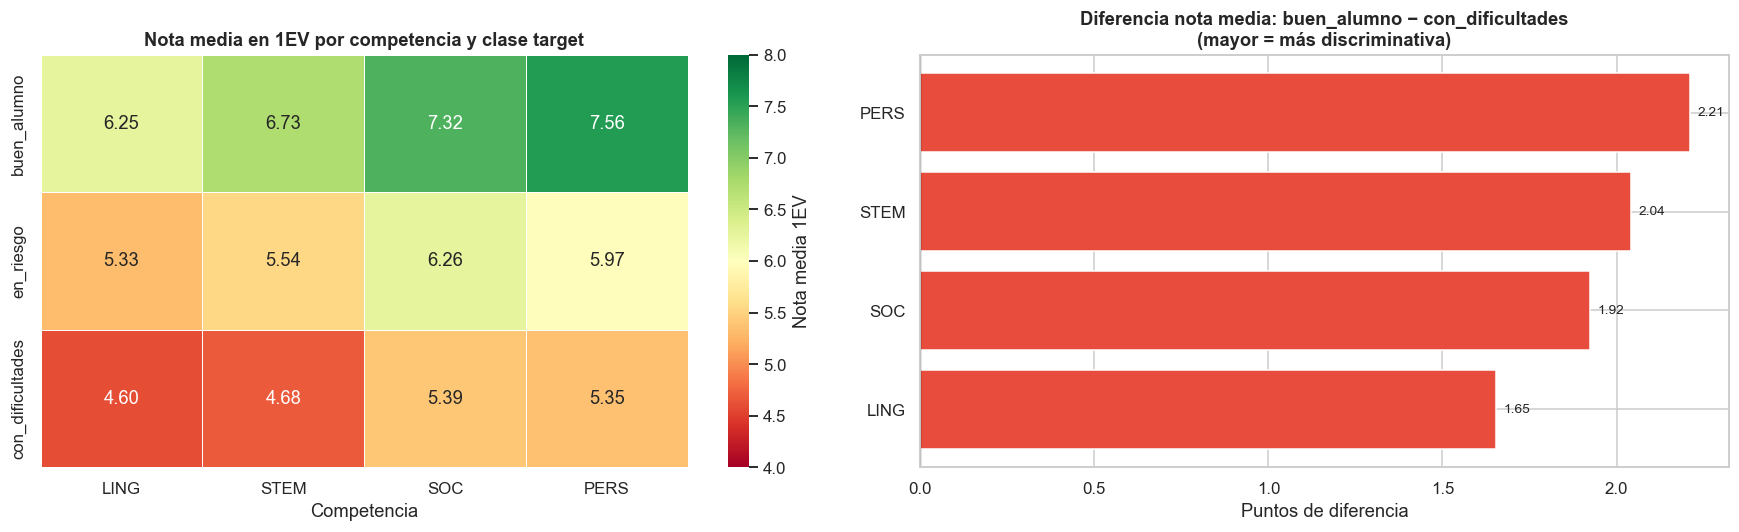

In [13]:
# Heatmap: nota_media por competencia × clase target
comps_ok = [c for c in COMPS if f'nota_media__{c}' in df.columns
            and df[f'nota_media__{c}'].notna().sum() >= 30]

heat_data = pd.DataFrame(index=CAT_ORDER)
for comp in comps_ok:
    col = f'nota_media__{comp}'
    heat_data[comp] = df.groupby('categoria_target')[col].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=4, vmax=8, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Nota media 1EV'})
axes[0].set_title('Nota media en 1EV por competencia y clase target',
                   fontweight='bold')
axes[0].set_xlabel('Competencia')
axes[0].set_ylabel('')

# Diferencia buen_alumno - con_dificultades
diff = heat_data.loc['buen_alumno'] - heat_data.loc['con_dificultades']
diff_sorted = diff.sort_values(ascending=True)
colors_diff = ['#e74c3c' if v > 1.5 else '#f39c12' if v > 0.8 else '#3498db'
               for v in diff_sorted.values]
axes[1].barh(diff_sorted.index, diff_sorted.values, color=colors_diff)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Diferencia nota media: buen_alumno − con_dificultades\n(mayor = más discriminativa)',
                   fontweight='bold')
axes[1].set_xlabel('Puntos de diferencia')
for i, v in enumerate(diff_sorted.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\4140483926.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\4140483926.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([f'{c}\n(n={n.get(c, 0)})' for c in CAT_ORDER], fontsize=7)
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\4140483926.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='categoria_target', y=col,
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\4140483926.py:21: UserWarning: set_ticklab

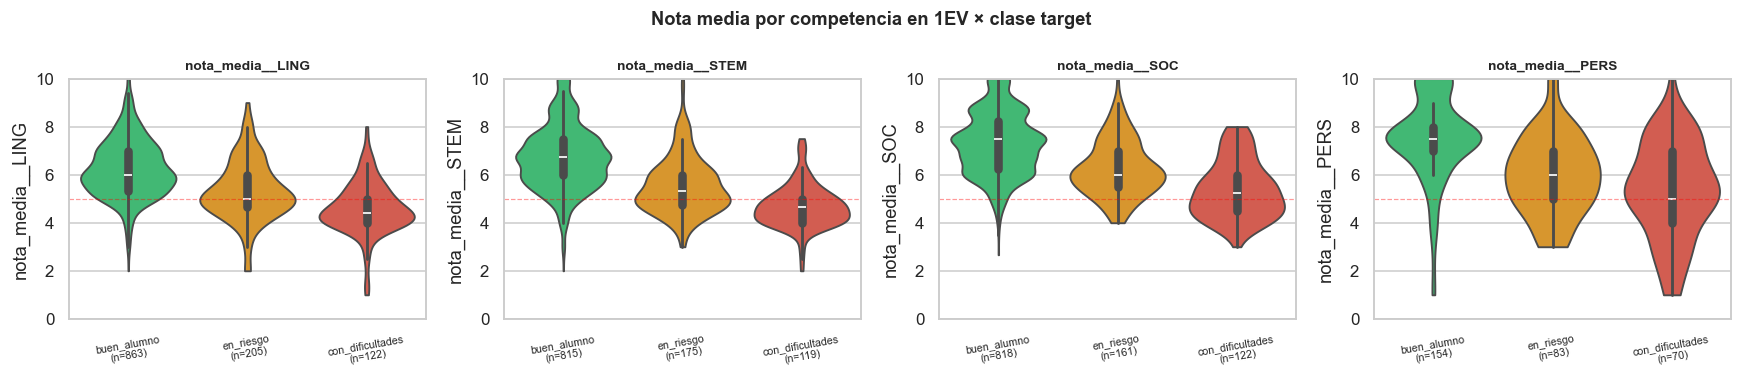

In [14]:
# Violin plots: nota_media por competencia × target (solo comps con buena cobertura)
n_comp = len(comps_ok)
ncols = 4
nrows = (n_comp + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, comp in enumerate(comps_ok):
    col = f'nota_media__{comp}'
    data_plot = df[['categoria_target', col]].dropna()
    sns.violinplot(data=data_plot, x='categoria_target', y=col,
                   order=CAT_ORDER, palette=PALETTE,
                   inner='box', ax=axes[i], cut=0)
    axes[i].set_title(f'nota_media__{comp}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].axhline(5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
    axes[i].set_ylim(0, 10)
    axes[i].tick_params(axis='x', rotation=10, labelsize=8)
    n = data_plot['categoria_target'].value_counts()
    axes[i].set_xticklabels([f'{c}\n(n={n.get(c, 0)})' for c in CAT_ORDER], fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Nota media por competencia en 1EV × clase target',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\268508260.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_pct[comp] = df.groupby('categoria_target')[col].mean() * 100
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\268508260.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_pct[comp] = df.groupby('categoria_target')[col].mean() * 100
C:\Users\emili\AppData\Local\Temp\ipykernel_25564\268508260.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

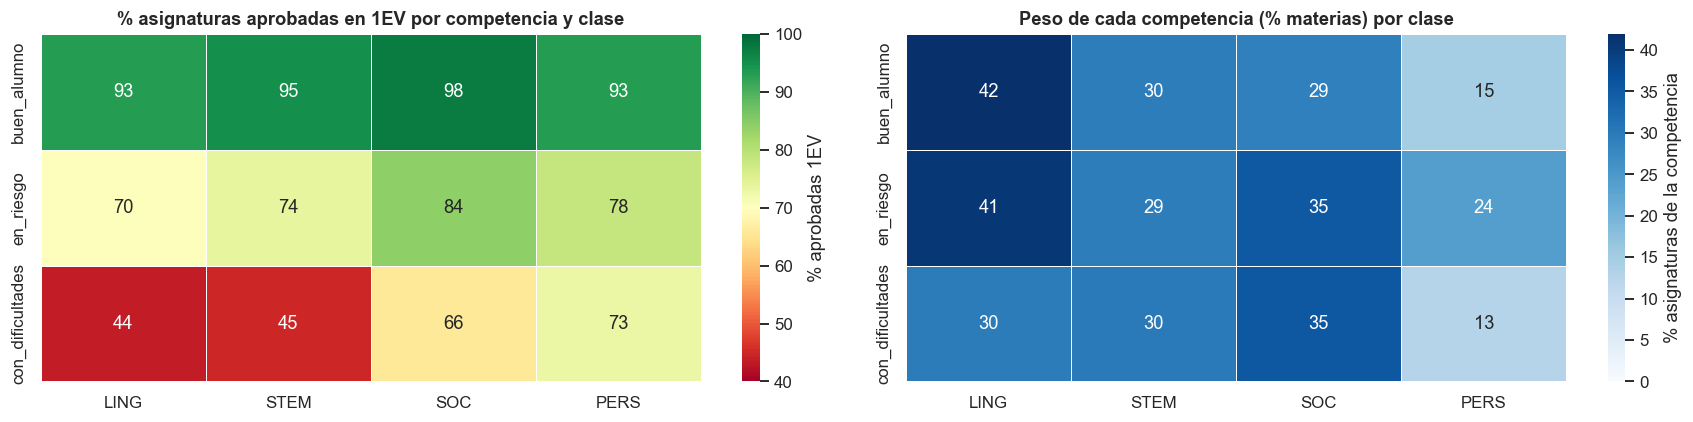

In [15]:
# Heatmap: pct_aprobado por competencia x clase target
heat_pct = pd.DataFrame(index=CAT_ORDER)
for comp in comps_ok:
    col = f'pct_aprobado__{comp}'
    if col in df.columns:
        heat_pct[comp] = df.groupby('categoria_target')[col].mean() * 100

# Heatmap: pct_asignaturas por competencia x clase target
heat_peso = pd.DataFrame(index=CAT_ORDER)
for comp in comps_ok:
    col = f'pct_asignaturas__{comp}'
    if col in df.columns:
        heat_peso[comp] = df.groupby('categoria_target')[col].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(heat_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=40, vmax=100, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': '% aprobadas 1EV'})
axes[0].set_title('% asignaturas aprobadas en 1EV por competencia y clase',
                   fontweight='bold')

sns.heatmap(heat_peso, annot=True, fmt='.0f', cmap='Blues',
            vmin=0, ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% asignaturas de la competencia'})
axes[1].set_title('Peso de cada competencia (% materias) por clase',
                   fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Ranking de correlaciones con el target

Correlación de Spearman de cada feature numérica con `target_num` (0=buen, 1=riesgo, 2=dificultades).

In [16]:
# Excluir columnas identificadoras y el propio target
EXCLUIR = {'GuidAlumno', 'Ejercicio', 'IdCentro', 'categoria_target', 'target_num',
           'origen_nota_final', 'numero_eval_max', 'NivEstudio', 'NivCurso',
           'Sexo_label', 'tiene_NEE', 'tiene_min'}

num_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUIR]

corrs = []
for col in num_cols:
    valid = df[[col, 'target_num']].dropna()
    if len(valid) < 30: continue
    r, p = stats.spearmanr(valid[col], valid['target_num'])
    corrs.append({'feature': col, 'rho': r, 'p': p,
                  'n': len(valid), 'abs_rho': abs(r)})

corr_df = pd.DataFrame(corrs).sort_values('abs_rho', ascending=False)
corr_df['sig'] = corr_df['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

print('Top 20 features por correlación Spearman con target_num:')
print(corr_df.head(20)[['feature', 'rho', 'p', 'sig', 'n']].to_string(index=False))

Top 20 features por correlación Spearman con target_num:
           feature    rho     p sig    n
         suspensos  0.996 0.000 *** 1205
   n_suspensos_1ev  0.664 0.000 *** 1205
  pct_aprobado_1ev -0.653 0.000 *** 1205
  nota_media_final -0.616 0.000 *** 1205
pct_aprobado__STEM -0.609 0.000 *** 1109
     nota_min__SOC -0.552 0.000 *** 1101
     mat__Sociales -0.551 0.000 ***  446
 pct_aprobado__SOC -0.545 0.000 *** 1101
pct_aprobado__LING -0.542 0.000 *** 1190
   mat__Tecnologia -0.541 0.000 ***  274
    nota_min__STEM -0.536 0.000 *** 1109
      nota_min_1ev -0.535 0.000 *** 1205
     mat__Ciencias -0.522 0.000 ***  986
    nota_media_1ev -0.511 0.000 *** 1205
  nota_media__STEM -0.510 0.000 *** 1109
  nota_media__PERS -0.483 0.000 ***  307
 total_asignaturas  0.482 0.000 *** 1205
    nota_max__PERS -0.479 0.000 ***  307
    nota_min__LING -0.472 0.000 *** 1190
  mat__Matematicas -0.453 0.000 *** 1085


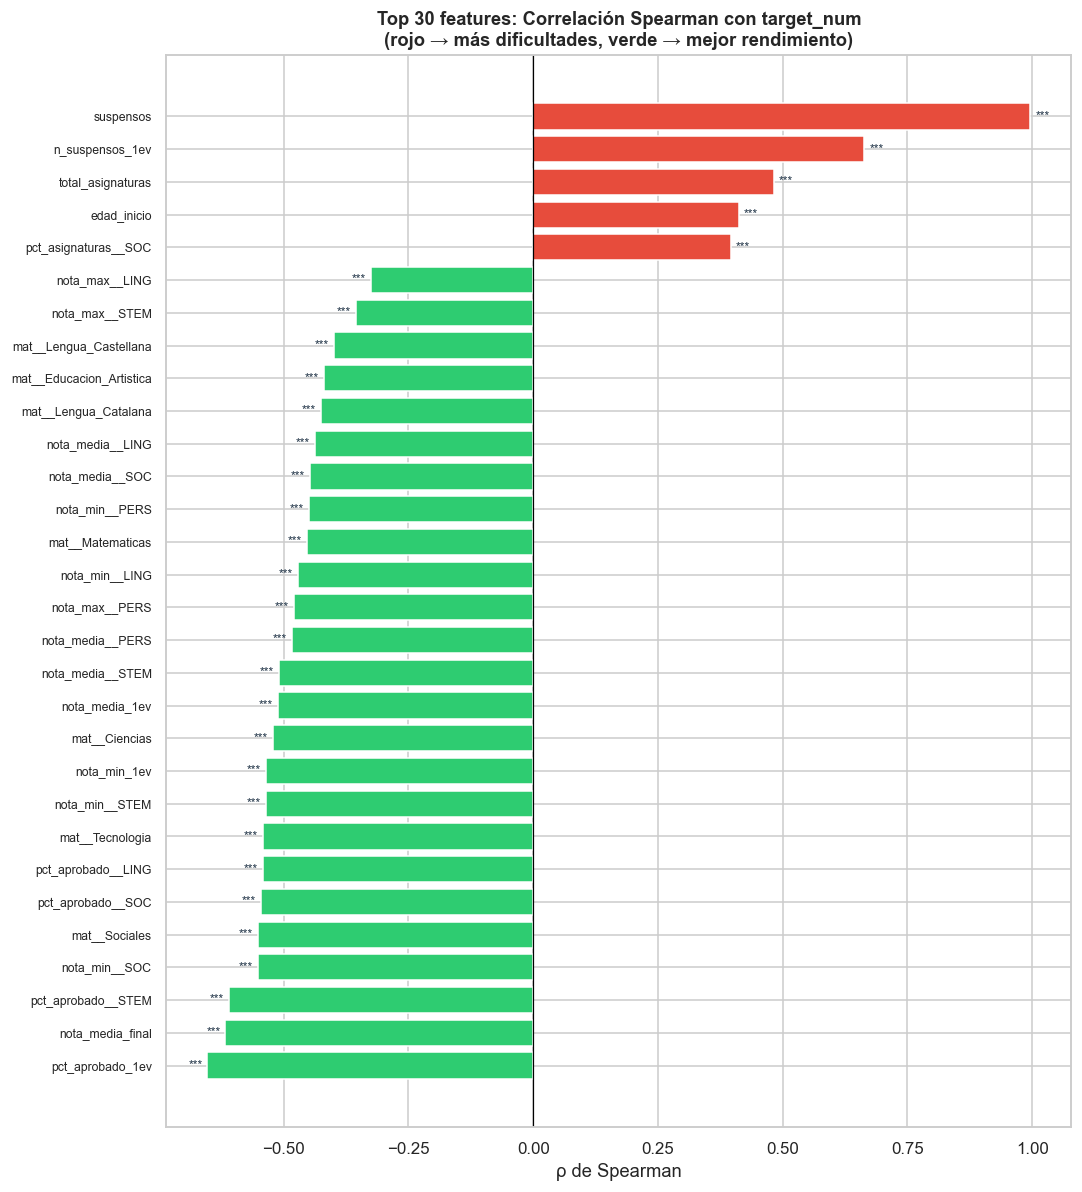


Total features con rho significativo (p<0.05): 45
Total features analizadas: 54


In [17]:
# Gráfico: top 30 features
top30 = corr_df.head(30).sort_values('rho')

fig, ax = plt.subplots(figsize=(10, 11))
colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in top30['rho']]
bars = ax.barh(top30['feature'], top30['rho'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

# Significancia
for i, (_, row) in enumerate(top30.iterrows()):
    x = row['rho'] + (0.01 if row['rho'] >= 0 else -0.01)
    ha = 'left' if row['rho'] >= 0 else 'right'
    ax.text(x, i, row['sig'], va='center', ha=ha, fontsize=8, color='#2c3e50')

ax.set_title('Top 30 features: Correlación Spearman con target_num\n'
             '(rojo → más dificultades, verde → mejor rendimiento)',
             fontweight='bold')
ax.set_xlabel('ρ de Spearman')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print(f'\nTotal features con rho significativo (p<0.05): {(corr_df["p"] < 0.05).sum()}')
print(f'Total features analizadas: {len(corr_df)}')

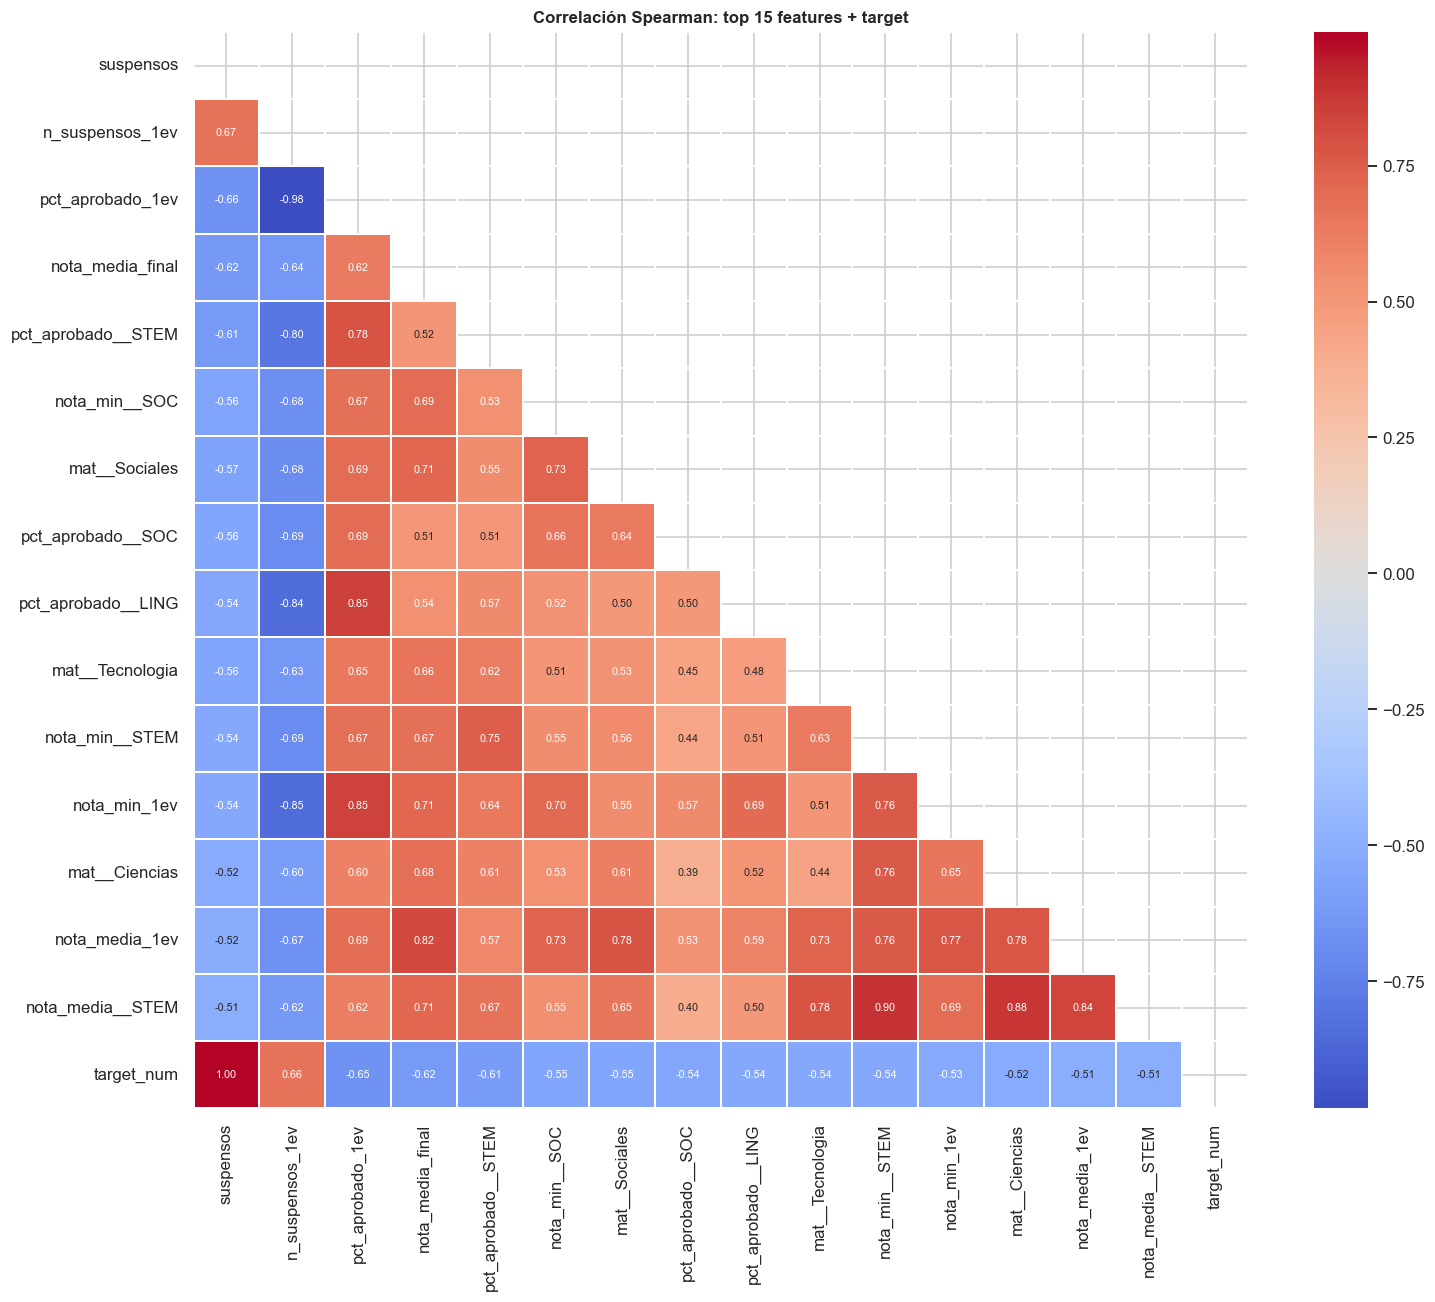

In [18]:
# Matriz de correlación entre las top 15 features + target
top15_feats = corr_df.head(15)['feature'].tolist()
corr_matrix = df[top15_feats + ['target_num']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlación Spearman: top 15 features + target',
              fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Análisis temporal — evolución por año

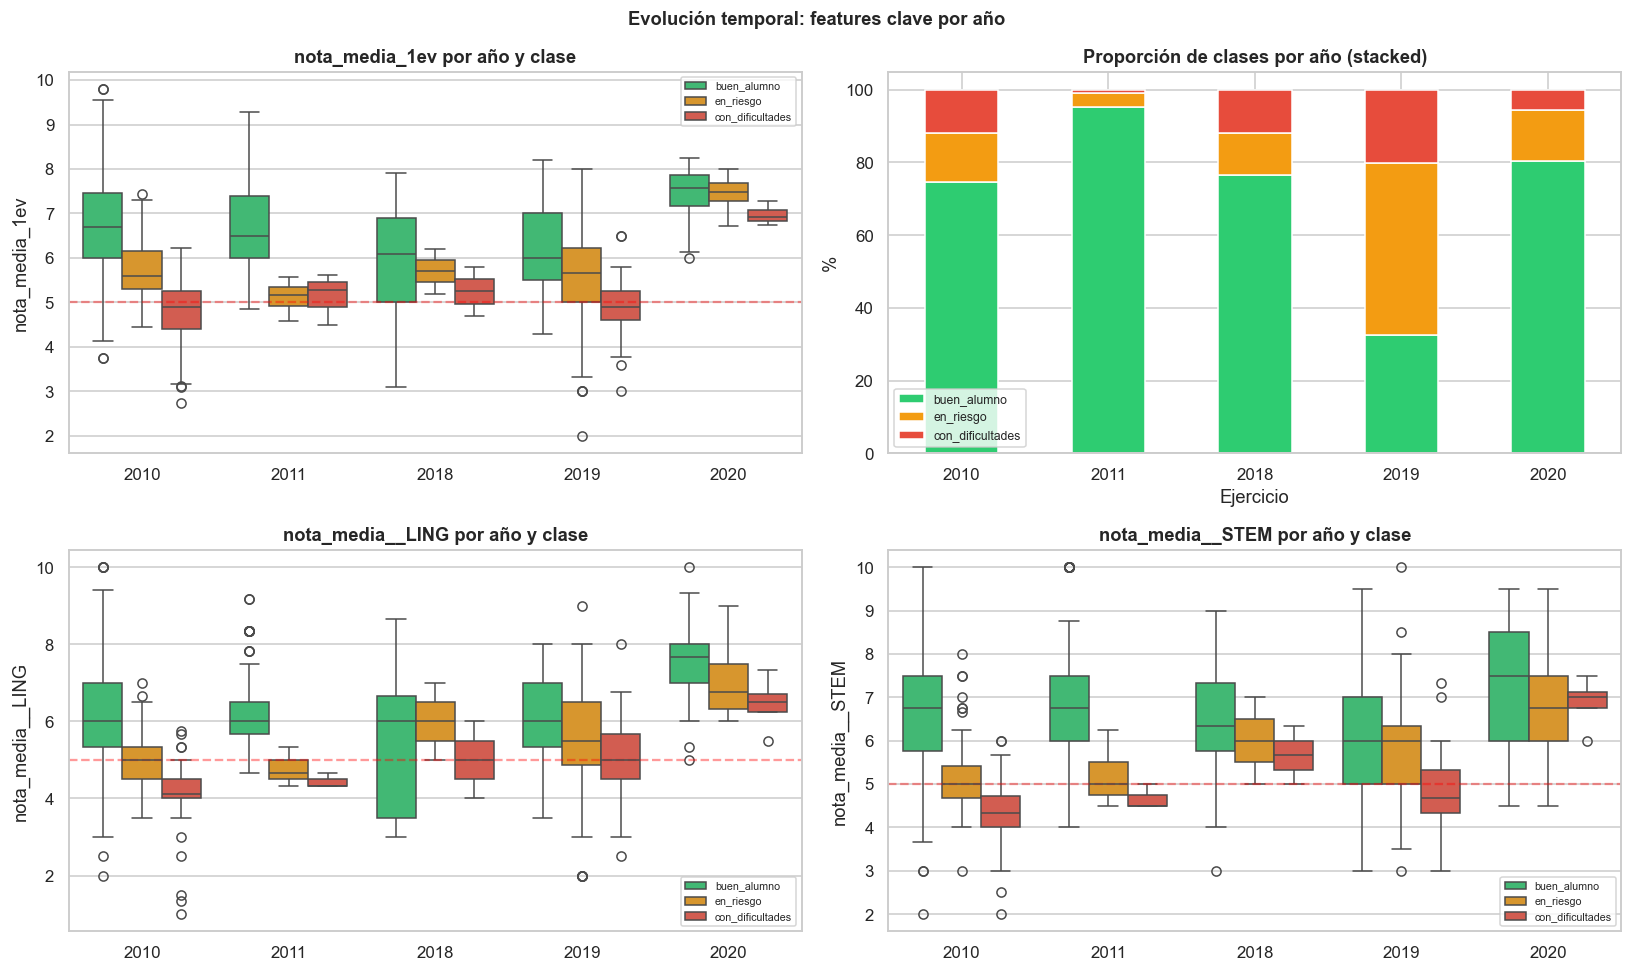

In [19]:
anios_ok = df.groupby('Ejercicio').filter(lambda x: len(x) >= 10)['Ejercicio'].unique()
df_anio = df[df['Ejercicio'].isin(anios_ok)].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# --- nota_media_1ev por año × target ---
sns.boxplot(data=df_anio.dropna(subset=['nota_media_1ev']),
            x='Ejercicio', y='nota_media_1ev',
            hue='categoria_target', hue_order=CAT_ORDER, palette=PALETTE,
            ax=axes[0, 0])
axes[0, 0].set_title('nota_media_1ev por año y clase', fontweight='bold')
axes[0, 0].axhline(5, color='red', linestyle='--', alpha=0.4)
axes[0, 0].legend(fontsize=7)
axes[0, 0].set_xlabel('')

# --- Proporción de clases por año ---
prop_anio = (df.groupby('Ejercicio')['categoria_target']
               .value_counts(normalize=True).unstack(fill_value=0)[CAT_ORDER] * 100)
prop_anio.plot(kind='bar', ax=axes[0, 1], color=PALETTE, edgecolor='white', stacked=True)
axes[0, 1].set_title('Proporción de clases por año (stacked)', fontweight='bold')
axes[0, 1].set_ylabel('%'); axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(fontsize=8)

# --- nota_media__LING por año ---
if 'nota_media__LING' in df.columns:
    sns.boxplot(data=df_anio.dropna(subset=['nota_media__LING']),
                x='Ejercicio', y='nota_media__LING',
                hue='categoria_target', hue_order=CAT_ORDER, palette=PALETTE,
                ax=axes[1, 0])
    axes[1, 0].set_title('nota_media__LING por año y clase', fontweight='bold')
    axes[1, 0].axhline(5, color='red', linestyle='--', alpha=0.4)
    axes[1, 0].legend(fontsize=7); axes[1, 0].set_xlabel('')

# --- nota_media__STEM por año ---
if 'nota_media__STEM' in df.columns:
    sns.boxplot(data=df_anio.dropna(subset=['nota_media__STEM']),
                x='Ejercicio', y='nota_media__STEM',
                hue='categoria_target', hue_order=CAT_ORDER, palette=PALETTE,
                ax=axes[1, 1])
    axes[1, 1].set_title('nota_media__STEM por año y clase', fontweight='bold')
    axes[1, 1].axhline(5, color='red', linestyle='--', alpha=0.4)
    axes[1, 1].legend(fontsize=7); axes[1, 1].set_xlabel('')

fig.suptitle('Evolución temporal: features clave por año', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Análisis por nivel educativo

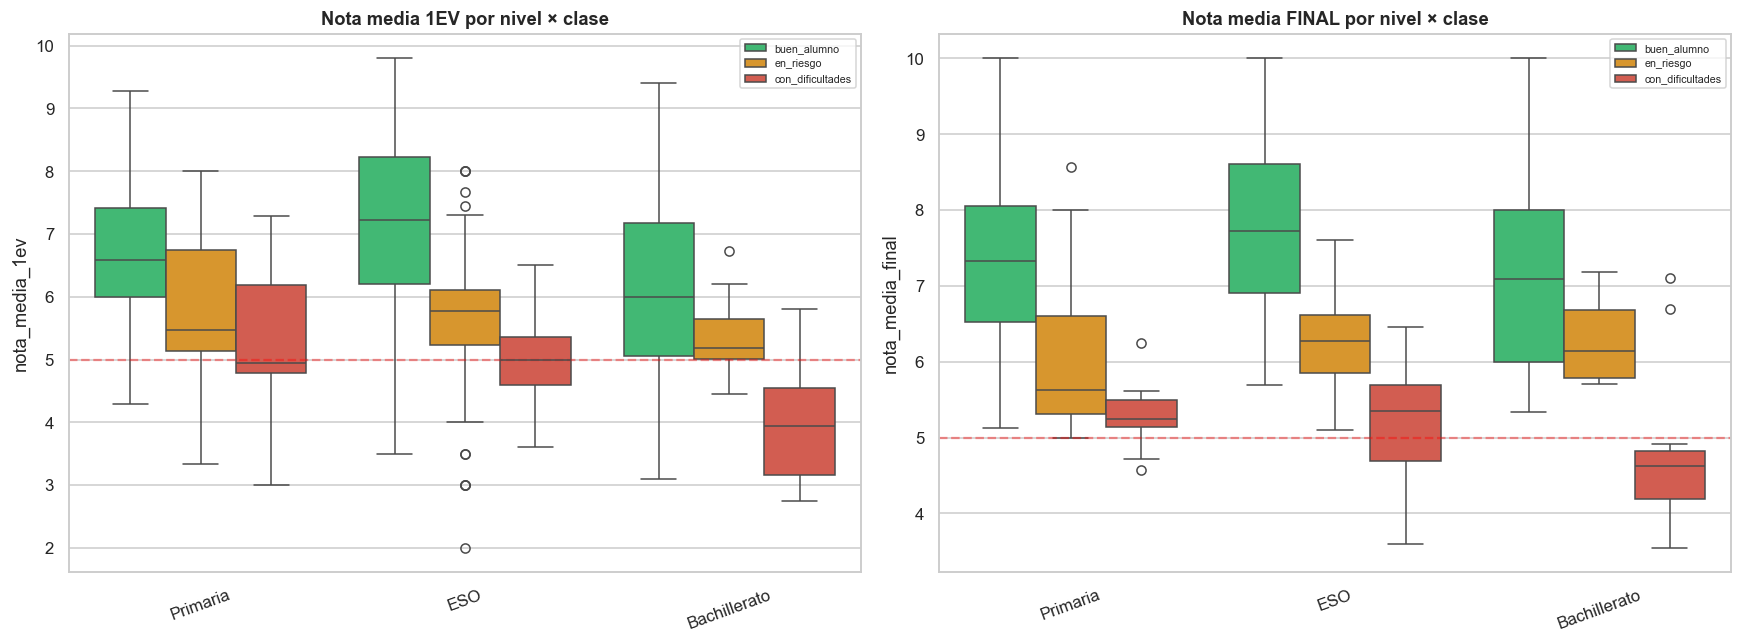

In [20]:
df_niv = df.dropna(subset=['NivEstudio']).copy()
niv_counts = df_niv['NivEstudio'].value_counts()
niveles_ok  = niv_counts[niv_counts >= 10].index.tolist()
df_niv = df_niv[df_niv['NivEstudio'].isin(niveles_ok)]

# nota_media_1ev + nota_media_final por nivel × target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_niv.dropna(subset=['nota_media_1ev']),
            x='NivEstudio', y='nota_media_1ev',
            hue='categoria_target', hue_order=CAT_ORDER, palette=PALETTE,
            ax=axes[0])
axes[0].set_title('Nota media 1EV por nivel × clase', fontweight='bold')
axes[0].axhline(5, color='red', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=7); axes[0].set_xlabel('')

sns.boxplot(data=df_niv.dropna(subset=['nota_media_final']),
            x='NivEstudio', y='nota_media_final',
            hue='categoria_target', hue_order=CAT_ORDER, palette=PALETTE,
            ax=axes[1])
axes[1].set_title('Nota media FINAL por nivel × clase', fontweight='bold')
axes[1].axhline(5, color='red', linestyle='--', alpha=0.4)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=7); axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

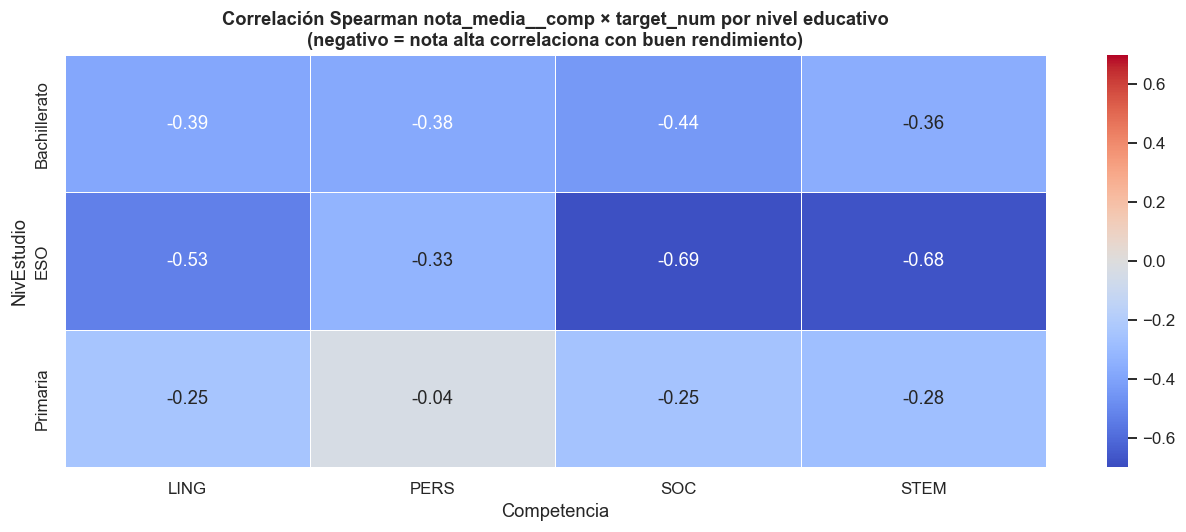

In [21]:
# Heatmap: correlación Spearman nota_media por competencia × nivel
rows_niv = []
for niv in niveles_ok:
    sub = df_niv[df_niv['NivEstudio'] == niv]
    for comp in comps_ok:
        col = f'nota_media__{comp}'
        if col not in df.columns: continue
        valid = sub[[col, 'target_num']].dropna()
        if len(valid) < 10: continue
        r, _ = stats.spearmanr(valid[col], valid['target_num'])
        rows_niv.append({'NivEstudio': niv, 'Competencia': comp, 'rho': r})

rho_niv = (pd.DataFrame(rows_niv)
             .pivot_table(index='NivEstudio', columns='Competencia', values='rho'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(rho_niv, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, vmin=-0.7, vmax=0.7)
ax.set_title('Correlación Spearman nota_media__comp × target_num por nivel educativo\n'
             '(negativo = nota alta correlaciona con buen rendimiento)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Estadísticos descriptivos por clase

In [22]:
# Tabla resumen: mean ± std para las features más relevantes por clase
TOP_FEATS = (
    ['nota_media_1ev', 'nota_min_1ev', 'nota_std_1ev', 'n_suspensos_1ev',
     'pct_aprobado_1ev', 'total_incidencias_1ev', 'no_justificadas_1ev']
    + [f'nota_media__{c}' for c in comps_ok]
    + [f'pct_aprobado__{c}' for c in comps_ok]
)
TOP_FEATS = [c for c in TOP_FEATS if c in df.columns]

summary = df.groupby('categoria_target')[TOP_FEATS].agg(['mean', 'std']).round(2)
summary

C:\Users\emili\AppData\Local\Temp\ipykernel_25564\641355494.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('categoria_target')[TOP_FEATS].agg(['mean', 'std']).round(2)


nota_media_1ev       nota_min_1ev       nota_std_1ev        \
                           mean   std         mean   std         mean   std   
categoria_target                                                              
buen_alumno               6.700 1.050        5.330 1.200        1.180 0.510   
en_riesgo                 5.740 0.980        4.150 1.290        1.500 0.670   
con_dificultades          4.950 0.770        3.380 1.070        1.420 0.510   

                 n_suspensos_1ev       pct_aprobado_1ev        \
                            mean   std             mean   std   
categoria_target                                                
buen_alumno                0.370 0.980            0.950 0.130   
en_riesgo                  1.700 1.520            0.760 0.230   
con_dificultades           4.260 2.060            0.540 0.210   

                 total_incidencias_1ev       no_justificadas_1ev        \
                                  mean   std                mean   std   
categoria_target                                                         
buen_alumno                      0.530 1.170               0.100 0.300   
en_riesgo                        0.570 0.690               0.490 0.500   
con_dificultades                 0.210 0.570               0.190 0.510   

                 nota_media__LING       nota_media__STEM        \
                             mean   std             mean   std   
categoria_target                                                 
buen_alumno                 6.250 1.200            6.730 1.340   
en_riesgo                   5.330 1.250            5.540 1.160   
con_dificultades            4.600 1.070            4.680 0.880   

                 nota_media__SOC       nota_media__PERS        \
                            mean   std             mean   std   
categoria_target                                                
buen_alumno                7.320 1.310            7.560 1.760   
en_riesgo                  6.260 1.150            5.970 1.640   
con_dificultades           5.390 1.190            5.350 2.000   

                 pct_aprobado__LING       pct_aprobado__STEM        \
                               mean   std               mean   std   
categoria_target                                                     
buen_alumno                   0.930 0.200              0.950 0.180   
en_riesgo                     0.700 0.340              0.740 0.300   
con_dificultades              0.440 0.360              0.450 0.350   

                 pct_aprobado__SOC       pct_aprobado__PERS        
                              mean   std               mean   std  
categoria_target                                                   
buen_alumno                  0.980 0.110              0.930 0.240  
en_riesgo                    0.840 0.230              0.780 0.380  
con_dificultades             0.660 0.300              0.730 0.440

In [23]:
# Tabla compacta mean (std) por clase — formato publicación
rows_pub = []
for feat in TOP_FEATS[:20]:  # primeras 20
    row = {'feature': feat}
    for cat in CAT_ORDER:
        sub = df.loc[df['categoria_target'] == cat, feat].dropna()
        row[cat] = f'{sub.mean():.2f} ± {sub.std():.2f}  (n={len(sub)})'
    rows_pub.append(row)

pub_df = pd.DataFrame(rows_pub).set_index('feature')
print('Estadísticos por clase (media ± desv. estándar):')
pub_df

Estadísticos por clase (media ± desv. estándar):


,buen_alumno,en_riesgo,con_dificultades
feature,,,
nota_media_1ev,6.70 ± 1.05 (n=867),5.74 ± 0.98 (n=213),4.95 ± 0.77 (n=125)
nota_min_1ev,5.33 ± 1.20 (n=867),4.15 ± 1.29 (n=213),3.38 ± 1.07 (n=125)
nota_std_1ev,1.18 ± 0.51 (n=852),1.50 ± 0.67 (n=190),1.42 ± 0.51 (n=124)
n_suspensos_1ev,0.37 ± 0.98 (n=867),1.70 ± 1.52 (n=213),4.26 ± 2.06 (n=125)
pct_aprobado_1ev,0.95 ± 0.13 (n=867),0.76 ± 0.23 (n=213),0.54 ± 0.21 (n=125)
total_incidencias_1ev,0.53 ± 1.17 (n=867),0.57 ± 0.69 (n=213),0.21 ± 0.57 (n=125)
no_justificadas_1ev,0.10 ± 0.30 (n=867),0.49 ± 0.50 (n=213),0.19 ± 0.51 (n=125)
nota_media__LING,6.25 ± 1.20 (n=863),5.33 ± 1.25 (n=205),4.60 ± 1.07 (n=122)
nota_media__STEM,6.73 ± 1.34 (n=815),5.54 ± 1.16 (n=175),4.68 ± 0.88 (n=119)


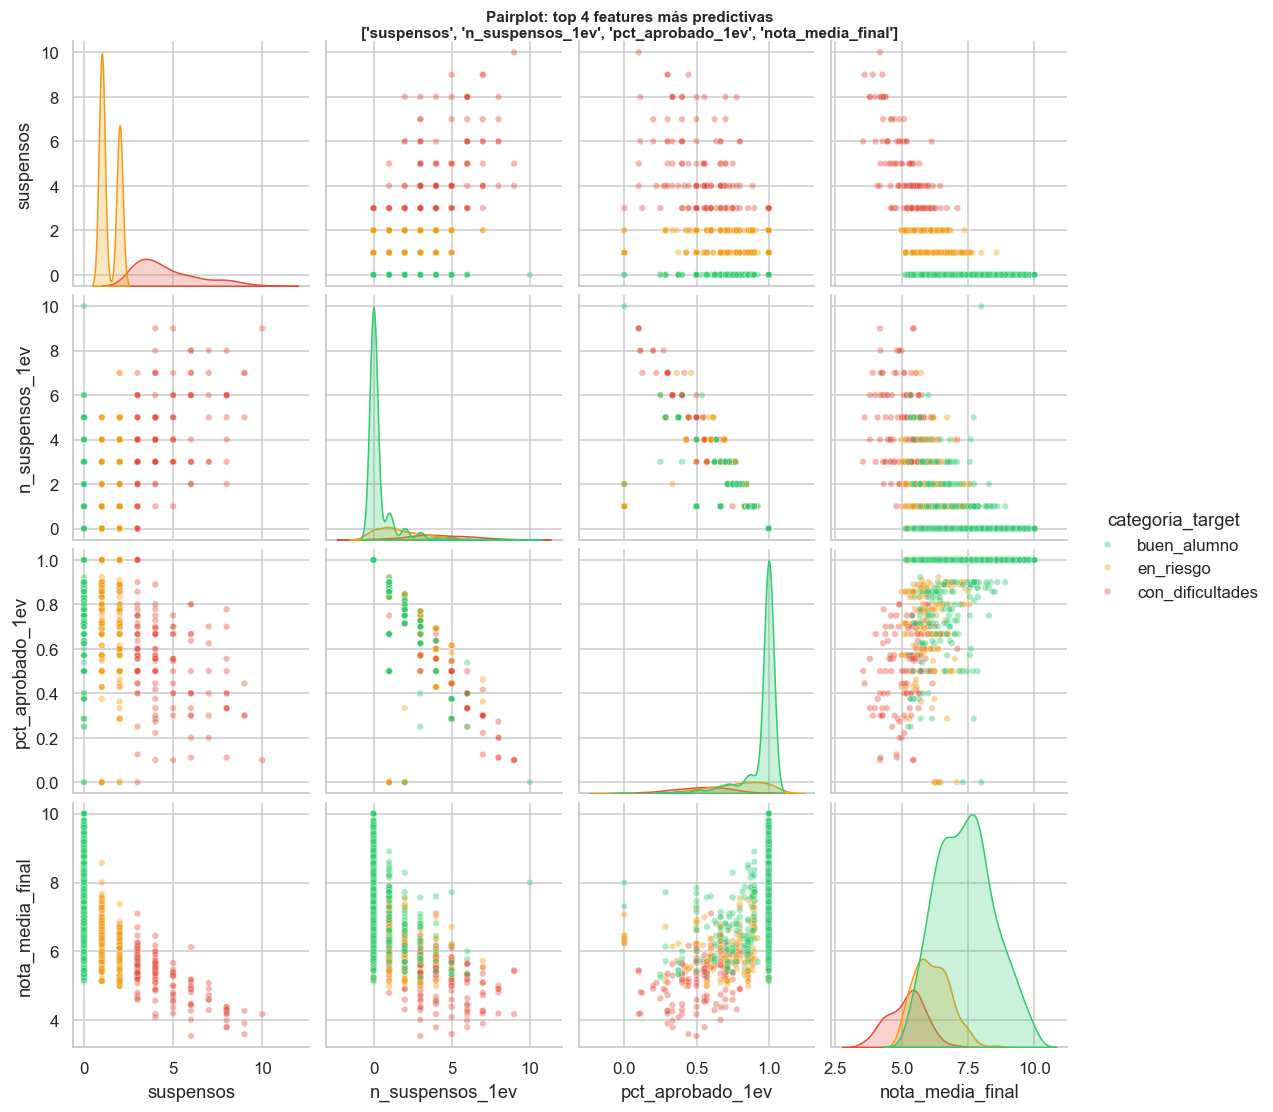

In [24]:
# Pairplot rápido: 4 features más predictivas
top4 = corr_df.head(4)['feature'].tolist()
pairdata = df[top4 + ['categoria_target']].dropna()

g = sns.pairplot(pairdata, hue='categoria_target', hue_order=CAT_ORDER,
                 palette=CAT_COLORS, plot_kws=dict(alpha=0.4, s=18),
                 diag_kind='kde')
g.fig.suptitle(f'Pairplot: top 4 features más predictivas\n{top4}',
               y=1.01, fontweight='bold', fontsize=10)
plt.show()

In [25]:
# Resumen final: qué variables discriminan mejor
top_sig = corr_df[corr_df['p'] < 0.05].head(20)

print('=' * 70)
print('RESUMEN EDA — FEATURES MÁS DISCRIMINATIVAS (Spearman p<0.05)')
print('=' * 70)
print(f'{"Feature":<35} {"rho":>6}  {"sig":>5}  {"n":>5}')
print('-' * 55)
for _, row in top_sig.iterrows():
    print(f'{row["feature"]:<35} {row["rho"]:>6.3f}  {row["sig"]:>5}  {int(row["n"]):>5}')

print('\n')
print('Balance de clases:')
for cat in CAT_ORDER:
    n = (df['categoria_target'] == cat).sum()
    print(f'  {cat:<22}: {n:>3}  ({n/len(df)*100:.1f}%)')
print(f'\nTotal: {len(df)} alumnos-año')

RESUMEN EDA — FEATURES MÁS DISCRIMINATIVAS (Spearman p<0.05)
Feature                                rho    sig      n
-------------------------------------------------------
suspensos                            0.996    ***   1205
n_suspensos_1ev                      0.664    ***   1205
pct_aprobado_1ev                    -0.653    ***   1205
nota_media_final                    -0.616    ***   1205
pct_aprobado__STEM                  -0.609    ***   1109
nota_min__SOC                       -0.552    ***   1101
mat__Sociales                       -0.551    ***    446
pct_aprobado__SOC                   -0.545    ***   1101
pct_aprobado__LING                  -0.542    ***   1190
mat__Tecnologia                     -0.541    ***    274
nota_min__STEM                      -0.536    ***   1109
nota_min_1ev                        -0.535    ***   1205
mat__Ciencias                       -0.522    ***    986
nota_media_1ev                      -0.511    ***   1205
nota_media__STEM            